In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
import ollama

In [2]:
dataset=pd.read_csv(r"C:\Users\beher\OneDrive\Desktop\ML\EDA\netflix_titles.csv")


In [3]:
dataset.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
dataset.shape

(8807, 12)

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
dataset.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

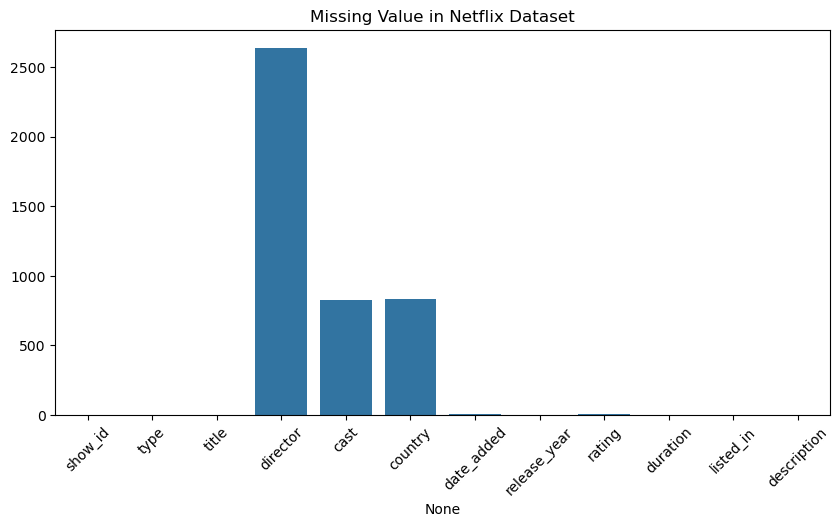

In [7]:
missing_values=dataset.isnull().sum()

plt.figure(figsize=(10,5))
sns.barplot(x=missing_values.index,y=missing_values.values)

plt.xticks(rotation=45)
plt.title("Missing Value in Netflix Dataset")
plt.show()

In [8]:
dataset['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

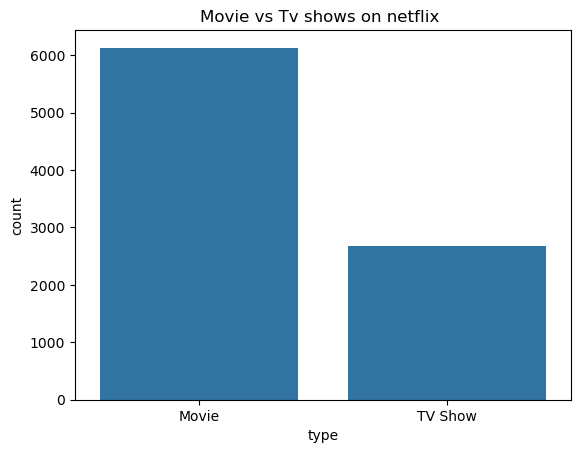

In [9]:
sns.countplot(x='type',data=dataset)
plt.title("Movie vs Tv shows on netflix ")
plt.show()

In [10]:
dataset['release_year'].value_counts().head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

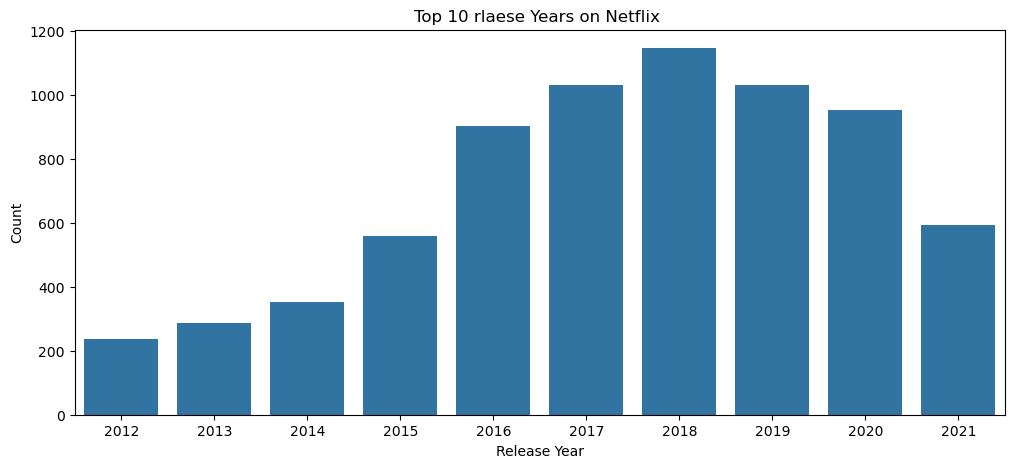

In [11]:
top_year=dataset['release_year'].value_counts().head(10)
plt.figure(figsize=(12,5))
sns.barplot(x=top_year.index,y=top_year.values)

plt.title("Top 10 rlaese Years on Netflix ")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

In [12]:
response = ollama.chat(
    model="llama3",
    messages=[
        {
            "role": "user",
            "content": "Netflix has more movies than TV shows. Explain this insight."
        }
    ]
)

print(response["message"]["content"])

A fascinating observation! While Netflix is known for its vast library of TV shows, it's not surprising that they have more movies overall. Here's why:

1. **Movie library inheritance**: When Netflix acquired the streaming rights to various movie studios' libraries, they inherited a massive collection of films. Many of these deals were made before TV show production was as prevalent on the platform.
2. **Catalog acquisition**: Netflix has consistently acquired the rights to large collections of movies from various studios and distributors, such as Miramax, Sony Pictures, and Warner Bros., among others. These acquisitions often include hundreds or thousands of titles, which contribute to the overall movie count.
3. **Indie film focus**: Netflix has a reputation for supporting independent filmmakers and releasing original movies that might not have found distribution otherwise. This focus on indie films means they've accumulated a significant number of smaller, art-house productions, whi

In [13]:
prompt = f"""
You are a data analyst.

Dataset Insight:
Netflix contains more Movies than TV Shows.

Give:
1. Short business insight
2. Possible reason
3. One recommendation

Keep answer concise.
"""

response = ollama.chat(
    model="llama3",
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

print(response["message"]["content"])

Here's the analysis:

**Short Business Insight:** Netflix's content strategy prioritizes movie offerings, catering to subscribers' preferences for feature films and original productions.

**Possible Reason:** The popularity of movies on streaming platforms like Netflix might be attributed to their self-contained nature, making them easier to consume in a single sitting. Additionally, the rise of franchise-based films (e.g., Marvel, Star Wars) has contributed to their appeal.

**Recommendation:** To further capitalize on this trend, Netflix could expand its original movie production slate while exploring opportunities for interactive movies and limited series that blur the lines between TV shows and feature films.


In [14]:
type_counts = dataset["type"].value_counts()

movies = type_counts["Movie"]
tvshows = type_counts["TV Show"]

prompt = f"""
You are a data analyst.

Dataset Insight:
Netflix contains {movies} Movies and {tvshows} TV Shows.

Give:
1. Short business insight
2. Possible reason
3. Recommendation

Keep answer concise.
"""

response = ollama.chat(
    model="llama3",
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

print(response["message"]["content"])

Here's my analysis:

**Business Insight:** Netflix has an impressive content library, with over 9,000 titles to choose from, catering to diverse tastes and preferences.

**Possible Reason:** The rapid growth in the number of TV shows might be attributed to the increasing demand for streaming original content, driven by the success of Netflix's own productions like "Stranger Things" and "The Crown".

**Recommendation:** To further capitalize on this trend, Netflix could consider increasing its investment in original TV show production, while also continuing to diversify its movie offerings to attract a broader audience.
